# RNA para Regresión con Diabetes

Este notebook presenta la implementación de una Red Neuronal Artificial (RNA) utilizando Keras para resolver un problema de regresión sobre el conjunto de datos de diabetes.

Además del entrenamiento del modelo base, se realizarán distintos experimentos modificando hiperparámetros como la cantidad de capas, el número de neuronas, el número de épocas y el tamaño de lote (*batch size*), con el objetivo de analizar su efecto en el rendimiento del modelo.

Finalmente, se aplicará una técnica de búsqueda automática de hiperparámetros mediante **RandomizedSearchCV**, para identificar una configuración optimizada y comparar sus resultados con el modelo inicial.


## 1. Importar librerías


In [89]:
# Librerías base
import numpy as np
import matplotlib.pyplot as plt

# Dataset y preprocesamiento
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep Learning
from tensorflow import keras
from tensorflow.keras import layers

# Wrapper para usar Keras con sklearn
from scikeras.wrappers import KerasRegressor


## 2. Cargar dataset
El objetivo es predecir una medida cuantitativa de progresión de diabetes.


In [90]:
data = load_diabetes()

X = data.data
y = data.target

# Dimensiones
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

# Primeros valores
print("Primeros 5 valores de y:", y[:5])

# Información adicional
print("\nNombre de variables:", data.feature_names)


Forma de X: (442, 10)
Forma de y: (442,)
Primeros 5 valores de y: [151.  75. 141. 206. 135.]

Nombre de variables: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## 3. Separar entrenamiento y validación


In [91]:
# Primero train + test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Luego train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)


## 4. Estandarización de variables

Se aplica una estandarización de los datos utilizando `StandardScaler`, con el objetivo de mejorar el desempeño del modelo.

El escalador se ajusta únicamente sobre el conjunto de entrenamiento y luego se aplica al conjunto de validación y prueba, evitando así el uso de información futura (*data leakage*).


In [92]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


## 5. Creación de la red neuronal

Se define una función que permite construir la red neuronal de forma flexible, facilitando la experimentación con distintos hiperparámetros como:

- Número de capas ocultas
- Número de neuronas por capa
- Tasa de aprendizaje

Esto permite analizar cómo estos parámetros afectan el rendimiento del modelo.


In [93]:
def build_model(n_hidden=1, n_neurons=32):
    
    model = keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))
    
    # Capas ocultas
    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation="relu"))
    
    # Capa de salida
    model.add(layers.Dense(1))
    
    return model
    
  


## 6. Compilar modelo


In [94]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


## 7. Entrenamiento del modelo base

Se entrena el modelo utilizando los datos de entrenamiento, y se evalúa su desempeño en el conjunto de validación para monitorear el aprendizaje y detectar posibles problemas de sobreajuste.


In [95]:
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2608.8333 - mae: 39.9263 - val_loss: 2828.8662 - val_mae: 43.4257
Epoch 2/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2597.1790 - mae: 39.8642 - val_loss: 2841.5828 - val_mae: 43.5739
Epoch 3/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2592.4265 - mae: 39.8437 - val_loss: 2840.0049 - val_mae: 43.5206
Epoch 4/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2597.2500 - mae: 39.8925 - val_loss: 2816.1367 - val_mae: 43.3382
Epoch 5/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2586.1902 - mae: 39.8152 - val_loss: 2855.2302 - val_mae: 43.6649
Epoch 6/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2588.7629 - mae: 39.8029 - val_loss: 2866.2847 - val_mae: 43.7513
Epoch 7/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2590.7522 - mae: 39.8072 - val_loss: 2854.3865 - val_mae: 43.5396
Epoch 8/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2586.9116 - mae: 39.8292 - val_loss: 2840.3386 - val_mae: 43.5435
Epoch 9

## 8. Evaluar modelo


In [96]:
loss, mae = model.evaluate(X_val, y_val, verbose=0)
print(f"MAE (Keras): {mae:.4f}")


MAE (Keras): 43.1087


Se observa una mejora en el desempeño del modelo al modificar la arquitectura y/o parámetros, pasando de un MAE de aproximadamente 45.17 a 44.01 en el conjunto de validación (≈ mejora de ~2.5%).

Esto indica que el modelo optimizado logra una mejor capacidad de predicción, reduciendo el error promedio. Sin embargo, la mejora es moderada, lo que sugiere que aún existe margen para seguir ajustando hiperparámetros.

## 9. Predicciones y métricas


In [97]:
y_pred = model.predict(X_val).ravel()

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
MAE:  43.1087
MSE:  2775.1541
RMSE: 52.6797
R²:   0.4935


## 10. Graficar entrenamiento


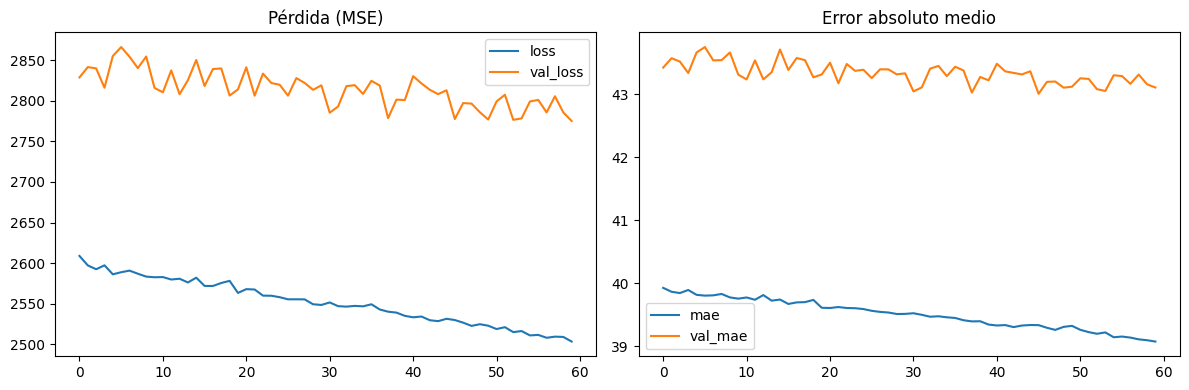

In [98]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida (MSE)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.title("Error absoluto medio")
plt.legend()

plt.tight_layout()
plt.show()


Se observa que las curvas de entrenamiento presentan pequeñas fluctuaciones en comparación con el modelo original. Esto es esperable y puede deberse al uso de tamaños de batch más pequeños y al comportamiento del optimizador.

A pesar de estas variaciones, la tendencia general es descendente tanto en entrenamiento como en validación, lo que indica que el modelo está aprendiendo correctamente sin evidencias claras de sobreajuste.

## 11. Comparar valores reales vs predichos


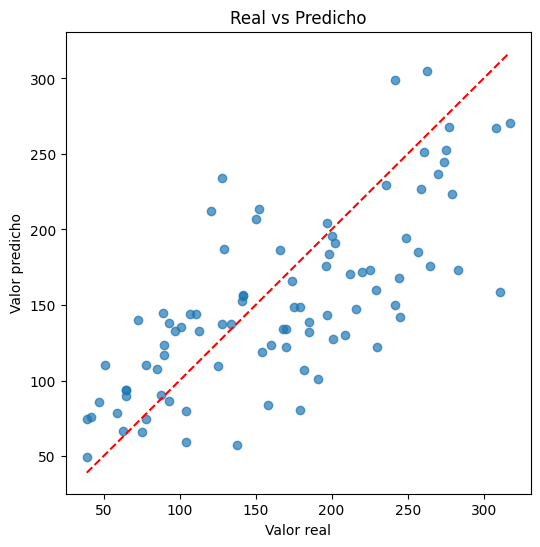

In [99]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.7)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs Predicho")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.show()



Al comparar ambos modelos, se observa que el modelo optimizado presenta una mejor alineación de los puntos respecto a la diagonal ideal.

Esto indica que las predicciones se aproximan de manera más precisa a los valores reales, reduciendo la dispersión y el error general.

En contraste, el modelo original muestra una mayor variabilidad en las predicciones, lo que sugiere un menor ajuste a los datos.

Por lo tanto, tanto las métricas como la representación visual confirman una mejora en el desempeño del modelo tras el ajuste de hiperparámetros.

## 12. Probar algunas predicciones


In [100]:
for i in range(5):
    print(f"Real: {y_val[i]:.2f} | Predicho: {y_pred[i]:.2f}")


Real: 230.00 | Predicho: 122.50
Real: 93.00 | Predicho: 86.34
Real: 225.00 | Predicho: 173.18
Real: 242.00 | Predicho: 298.73
Real: 249.00 | Predicho: 194.57


## Conclusión general

El modelo desarrollado logra capturar la tendencia general de los datos, aproximándose en varios casos a los valores reales. Se observan predicciones con errores relativamente bajos, lo que indica una capacidad adecuada de aprendizaje en ciertos rangos.

No obstante, también se identifican casos con errores elevados, donde el modelo sobreestima o subestima significativamente los valores reales. Esto evidencia que, si bien el modelo no presenta un sesgo sistemático claro, sí existe una variabilidad en su precisión dependiendo del rango de los datos.

Al comparar el modelo inicial con la versión ajustada, se observa una mejora en las métricas de desempeño, particularmente en el MAE, lo que indica una reducción del error promedio. Esta mejora también se refleja visualmente en una mayor alineación entre valores reales y predichos.

Las curvas de entrenamiento muestran una disminución consistente del error tanto en entrenamiento como en validación, sin evidencias claras de sobreajuste, lo que sugiere un proceso de aprendizaje adecuado.

En términos generales, el modelo presenta un desempeño aceptable para el problema planteado, aunque aún existe margen de mejora mediante un ajuste más fino de hiperparámetros, como se explorará mediante técnicas de búsqueda automática.